# Proyek Akhir: Menyelesaikan Permasalahan Human Resource pada Perusahaan Jaya Jaya Maju

- Nama: Rafif Idris Ardhana
- Email: a005ybm405@devacademy.id
- Id Dicoding:A005YBM405

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib

import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan diguankan

In [ ]:
df = pd.read_csv("/content/employee_data.csv")
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

### Assesing Data

In [ ]:
# Cek shape data
df.shape

(1470, 35)

Dataset memiliki 1.470 baris dan 35 kolom

In [ ]:
# Cek informasi data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

Dataset memiliki kombinasi tipe data yaitu object, integer, dan float

In [ ]:
# Cek missing value
df.isna().sum()

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


Terdapat missing value pada kolom attrition sebanyak 412 baris

In [ ]:
# Cek duplikasi data
print("Jumlah duplikasi data: ", df.duplicated().sum())

Jumlah duplikasi data:  0


Tidak terdapat duplikasi data pada dataset

### Cleaning Data

In [ ]:
# Handling missing value
df_employee = df.dropna()
df_employee.isna().sum()

,0
EmployeeId,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


Baris pada kolom attrition yang memiliki missing value dihandle dengan cara dihapus dan membuat dataset baru

In [ ]:
# Cek data shape
print("Jumlah baris sebelum dibersihkan: ", df.shape[0], ", Jumlah kolom: ", df.shape[1])
print("Jumlah baris setelah dibersihkan: ", df_employee.shape[0], ", Jumlah kolom: ", df_employee.shape[1])

Jumlah baris sebelum dibersihkan:  1470 , Jumlah kolom:  35
Jumlah baris setelah dibersihkan:  1058 , Jumlah kolom:  35


Dataset terbaru memiliki 1.058 baris dan 35 kolom

In [ ]:
# Menyimpan data hasil cleaning
df_employee.to_csv("employee_data_cleaned.csv", index=False)

Data hasil cleaning disimpan ke dalam format csv sebagai bahan dataset pada dashboard

### Exploratory Data Analysis

           Jumlah karyawan  Persentase
Attrition                             
0.0                    879        83.1
1.0                    179        16.9


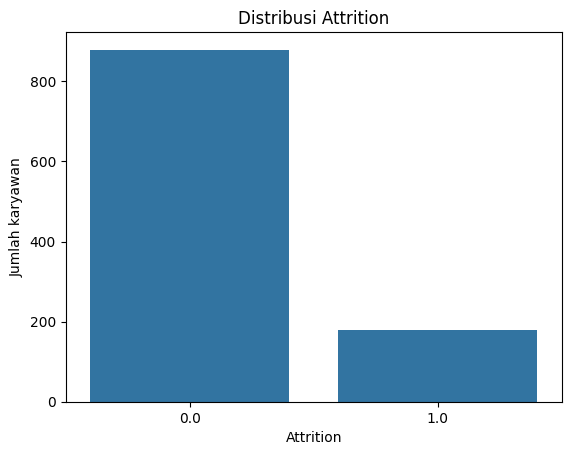

In [ ]:
# Distribusi kolom target "Attrition"
count = df_employee["Attrition"].value_counts()
percent = 100*df_employee["Attrition"].value_counts(normalize=True)
df_attrition = pd.DataFrame({"Jumlah karyawan": count, "Persentase": percent.round(1)})
print(df_attrition)

# Visualisasi distribusi
sns.countplot (x="Attrition", data=df_employee)
plt.title ("Distribusi Attrition")
plt.ylabel("Jumlah karyawan")
plt.show()

Dari data persentase di atas dapat disimpulkan bahwa 16.9% (179 orang) karyawan keluar. Selebihnya merupakan karyawan yang masih aktif bekerja dan belum keluar dengan persentase 83.1% (879 orang)

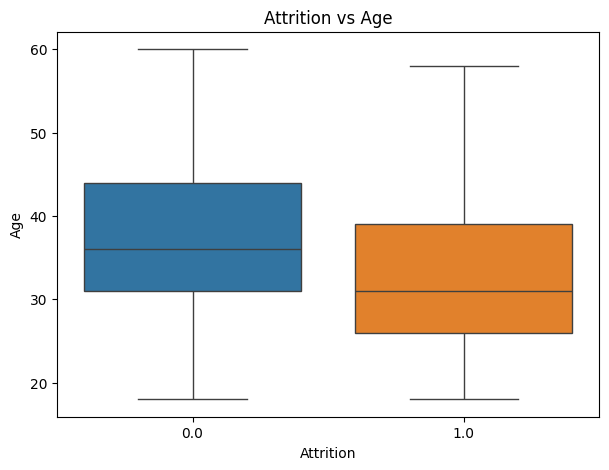

In [ ]:
# Analisis Attrition vs Age
plt.figure(figsize=(7,5))
sns.boxplot(data=df_employee, x='Attrition', y='Age', palette="tab10")
plt.title('Attrition vs Age')
plt.show()

Dari grafik boxplot di atas, karyawan yang lebih muda cenderung memiliki kemungkinan lebih tinggi untuk keluar dari perusahaan.
Ini bisa disebabkan oleh pencarian pengalaman, jenjang karier awal, atau ketidakcocokan budaya/peran dengan perusahaan.

Department
Sales                     20.7
Human Resources           15.8
Research & Development    15.3
Name: count, dtype: float64


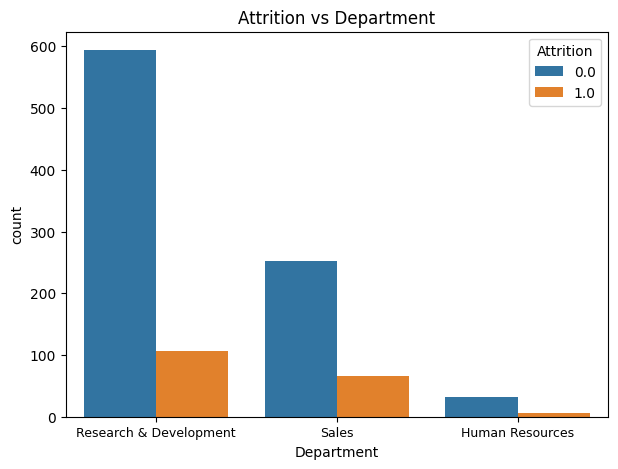

In [ ]:
# Analisis Attrition vs Department

# Hitung total karyawan per department
employee_per_department = df_employee["Department"].value_counts()
# Hitung jumlah attrition per department
attrition_per_department = df_employee[df_employee['Attrition'] == 1]['Department'].value_counts()
# Hitung persentase attrition
attrition_department_percentage = (attrition_per_department / employee_per_department) * 100
# Menampilkan persentase attrition di setiap department
print(attrition_department_percentage.sort_values(ascending=False).round(1))

# Visualisasi analisis
plt.figure(figsize=(7,5))
sns.countplot(x='Department', hue='Attrition', data=df_employee)
plt.title('Attrition vs Department')
plt.xticks(fontsize=9)
plt.show()

Attrition lebih sering terjadi di departemen dengan karyawan lebih banyak yaitu R&D. Tapi jika melihat proporsi (jumlah yang keluar dibanding total), department Sales memiliki tingkat keluar yang lebih tinggi (20.7%) daripada HR (15.8) dan R&D (15.3%)

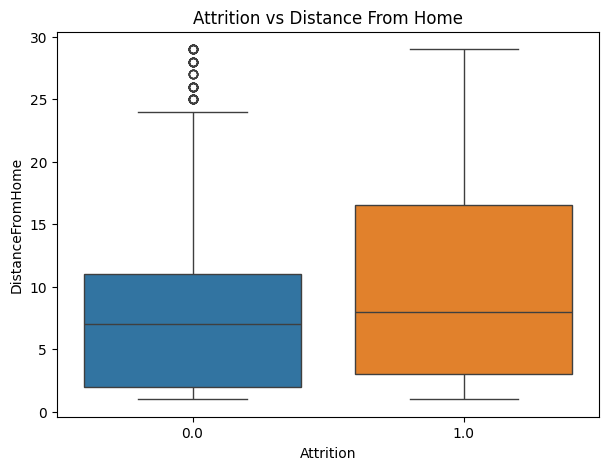

In [ ]:
# Analisis Attrition vs Distance From Home
plt.figure(figsize=(7,5))
sns.boxplot(data=df_employee, x='Attrition', y='DistanceFromHome', palette="tab10")
plt.title('Attrition vs Distance From Home')
plt.show()

Dari grafik boxplot di atas, karyawan dengan jarak rumah yang cukup jauh dengan tempat kerja cenderung keluar. Hal ini kemungkinan dapat disebabkan oleh ongkos transportasi atau ketidaknyaman jika pergi bekerja tetapi perlu menempuh jarak yang jauh

JobRole
Sales Representative         43.1
Laboratory Technician        26.1
Human Resources              20.0
Research Scientist           17.8
Sales Executive              16.8
Healthcare Representative     9.1
Manufacturing Director        6.5
Manager                       6.3
Research Director             3.2
Name: count, dtype: float64


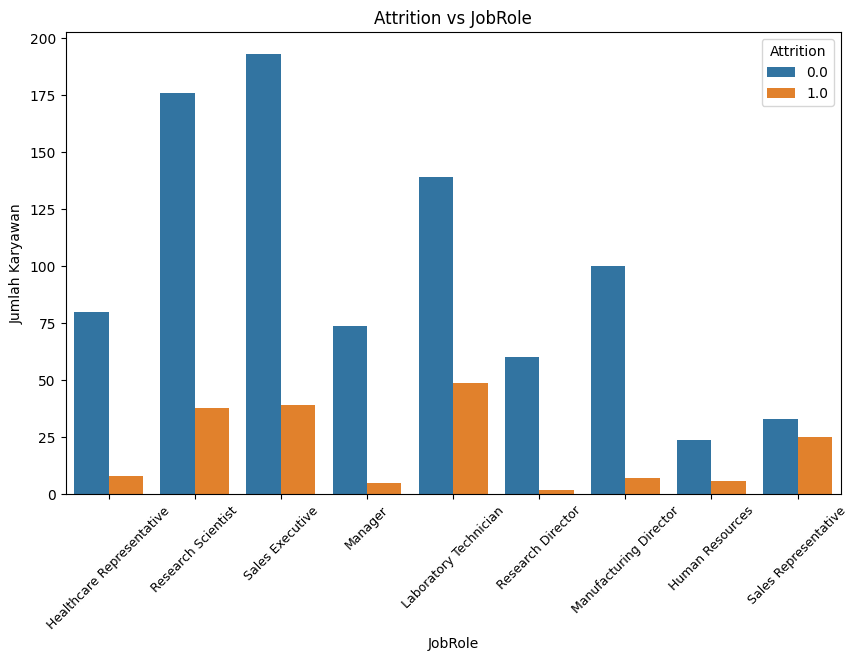

In [ ]:
# Analisis Attrition vs Job Role

# Hitung total karyawan per department
employee_per_jobrole = df_employee["JobRole"].value_counts()
# Hitung jumlah attrition per department
attrition_per_jobrole = df_employee[df_employee['Attrition'] == 1]['JobRole'].value_counts()
# Hitung persentase attrition
attrition_jobrole_percentage = (attrition_per_jobrole / employee_per_jobrole) * 100
# Menampilkan persentase attrition di setiap department
print(attrition_jobrole_percentage.sort_values(ascending=False).round(1))

# Visualisasi analisis
plt.figure(figsize=(10,6))
sns.countplot(data=df_employee, x='JobRole', hue='Attrition')
plt.title('Attrition vs JobRole')
plt.xlabel('JobRole')
plt.ylabel('Jumlah Karyawan')
plt.xticks(rotation=45, fontsize=9)
plt.show()

Dari grafik di atas, JobRole Laboratory Technician memiliki banyak karyawan yang keluar, tetapi jika melihat proporsi (jumlah yang keluar dibanding total), JobRole Sales Representative memiliki tingkat karyawan keluar lebih tinggi (43.1%) dibandingkan dengan JobRole Laboratory Technician (26.1%)

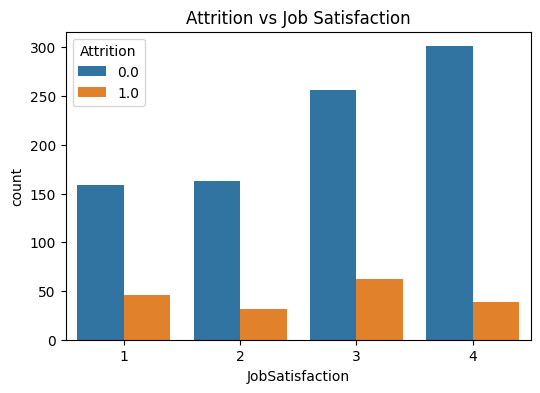

In [ ]:
# Analisis Attrition vs Job Satisfaction
plt.figure(figsize=(6,4))
sns.countplot(data=df_employee, x='JobSatisfaction', hue='Attrition')
plt.title('Attrition vs Job Satisfaction')
plt.xlabel('JobSatisfaction')
plt.show()

Job Satisfaction:
- 1: Low
- 2: Medium
- 3: High
- 4: Very High

Dari grafik di atas, karyawan dengan Job Satisfaction yang rendah cenderung keluar dari perusahaan. Hal ini dapat disebabkan adanya ketidakpuasan dalam bekerja. Sedangkan karyawan dengan Job Satisfaction yang tinggi cenderung bertahan.

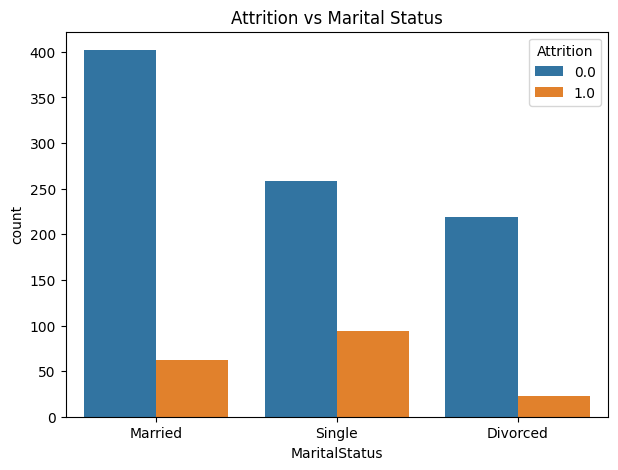

In [ ]:
# Analisis Attrition vs Marital Status
plt.figure(figsize=(7,5))
sns.countplot(data=df_employee, x='MaritalStatus', hue='Attrition')
plt.title('Attrition vs Marital Status')
plt.xlabel('MaritalStatus')
plt.show()

Dari grafik di atas, karyawan yang berstatus "Married" cenderung bertahan, dan karyawan dengan status "Single" lebih banyak keluar. Hal ini kemungkinan dapat disebabkan karena memiliki fleksibilitas tinggi untuk mengeksplor diri dan belum berkeluarga

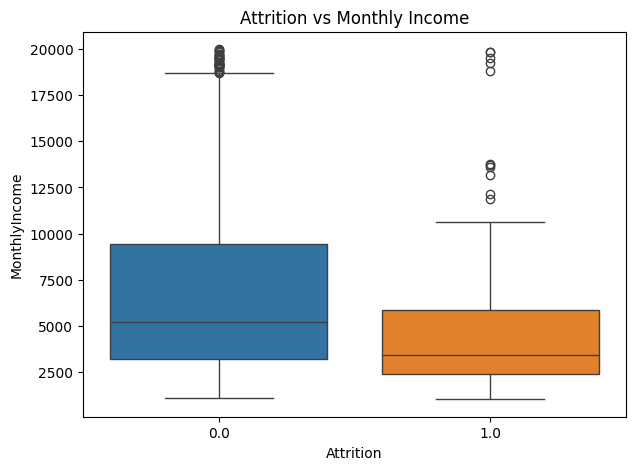

In [ ]:
# Analisis Attrition vs Monthly Income
plt.figure(figsize=(7,5))
sns.boxplot(data=df_employee, x='Attrition', y='MonthlyIncome', palette="tab10")
plt.title('Attrition vs Monthly Income')
plt.show()

Dari grafik boxplot di atas, terlihat karyawan yang keluar (Attrition = 1) umumnya memiliki pendapatan bulanan yang lebih rendah dibandingkan yang bertahan (Attrition = 0)

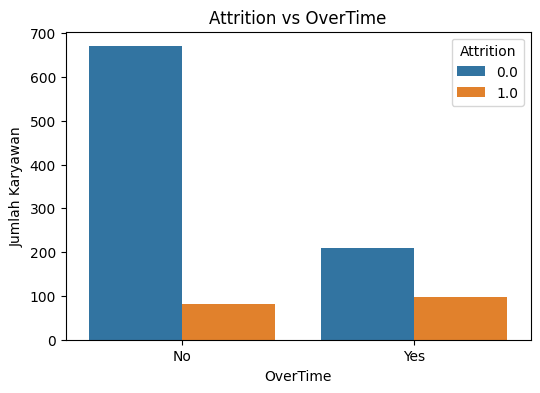

In [ ]:
# Analisis Attrition vs OverTime
plt.figure(figsize=(6,4))
sns.countplot(data=df_employee, x='OverTime', hue='Attrition')
plt.title('Attrition vs OverTime')
plt.xlabel('OverTime')
plt.ylabel('Jumlah Karyawan')
plt.show()

Dari grafik di atas, karyawan yang sering lembur ("OverTime = Yes") memiliki tingkat attrition lebih tinggi dibandingkan yang tidak lembur. Sedangkan karyawan yang tidak lembur ("OverTime = No") cenderung bertahan

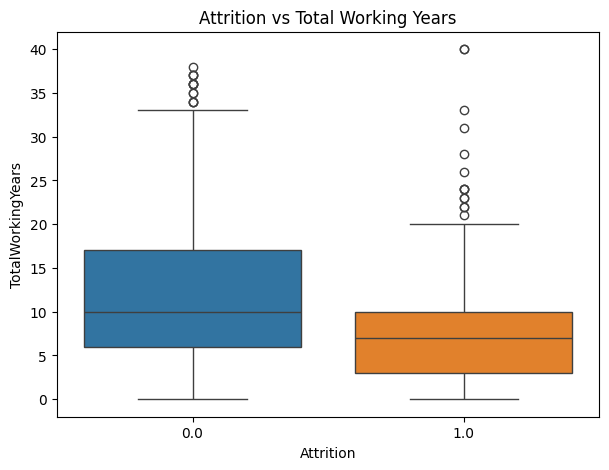

In [ ]:
# Analisis Attrition vs Total Working Years
plt.figure(figsize=(7,5))
sns.boxplot(data=df_employee, x='Attrition', y='TotalWorkingYears', palette="tab10")
plt.title('Attrition vs Total Working Years')
plt.show()

Dari grafik boxplot di atas, karyawan dengan total pengalaman kerja yang sudah lama, cenderung kecil kemungkinan mereka untuk resign. Sedangkan karyawan yang resign cenderung memiliki pengalaman kerja lebih sedikit atau baru.

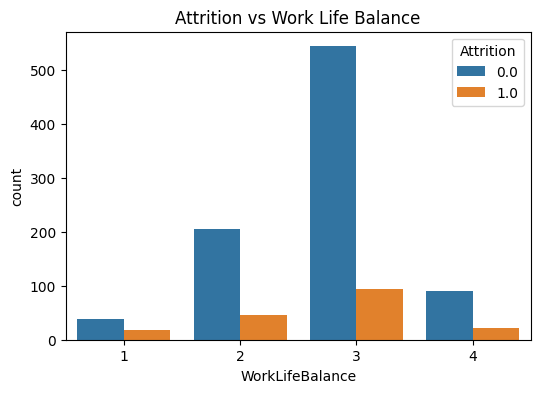

In [ ]:
# Analisis Attrition vs Work Life Balance
plt.figure(figsize=(6,4))
sns.countplot(data=df_employee, x='WorkLifeBalance', hue='Attrition')
plt.title('Attrition vs Work Life Balance')
plt.xlabel('WorkLifeBalance')
plt.show()

Work Life Balance:
- 1: Low
- 2: Good
- 3: Excellent
- 4: Outstanding

Dari grafik di atas, karyawan dengan keseimbangan kehidupan kerja yang rendah "Low", cenderung keluar dari perusahaan. Hal ini dapat disebabkan frustasi atau kelelahan dalam melakukan pekerjaan

Nilai Korelasi terhadap 'Attrition':
OverTime                    0.255856
MaritalStatus               0.177989
DistanceFromHome            0.078074
Department                  0.060796
JobRole                     0.056146
EducationField              0.040568
NumCompaniesWorked          0.037429
MonthlyRate                 0.023299
Gender                      0.015887
PerformanceRating           0.007755
PercentSalaryHike           0.004907
BusinessTravel             -0.008008
HourlyRate                 -0.017524
EmployeeId                 -0.017912
YearsSinceLastPromotion    -0.031944
Education                  -0.032631
TrainingTimesLastYear      -0.047859
DailyRate                  -0.051992
RelationshipSatisfaction   -0.053417
WorkLifeBalance            -0.059556
JobSatisfaction            -0.091751
EnvironmentSatisfaction    -0.132848
YearsAtCompany             -0.135134
JobInvolvement             -0.150196
YearsWithCurrManager       -0.155962
YearsInCurrentRole         -0.158757
M

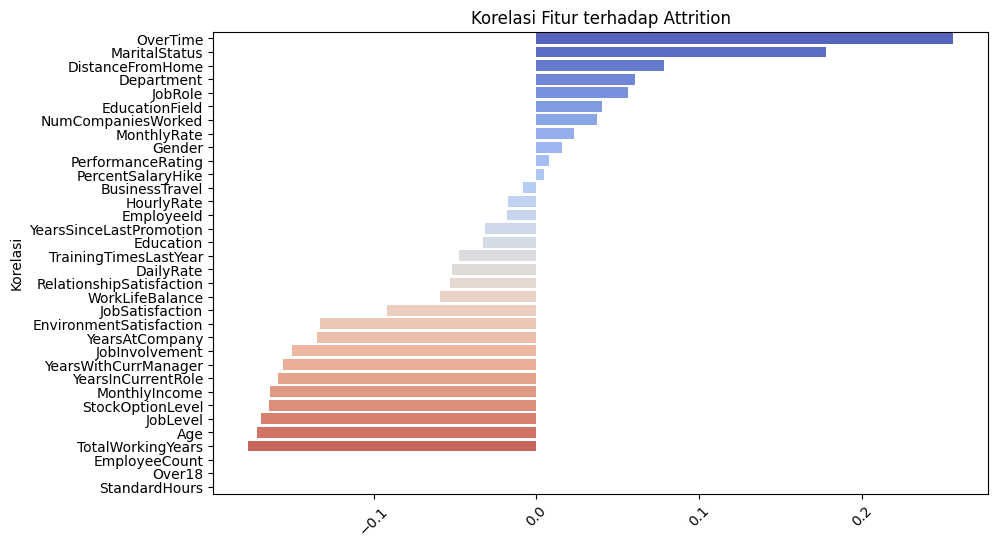

In [ ]:
# Correlation Feature terhadap Attrition

df_encoded = df_employee.copy()

# Encode kolom kategorikal
label_encoder_df = LabelEncoder()
categorical_columns = df_encoded.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    df_encoded[column] = label_encoder_df.fit_transform(df_encoded[column])

# Hitung korelasi antar kolom
corr = df_encoded.corr()

# Ambil korelasi terhadap target 'Attrition' (misalnya) atau yang ingin kamu analisis
corr_attrition = corr['Attrition'].sort_values(ascending=False)

# Hapus kolom 'Attrition' dari data yang akan dipakai untuk visualisasi
corr_attrition = corr_attrition.drop('Attrition')

# Tampilkan nilai korelasi
print("Nilai Korelasi terhadap 'Attrition':")
print(corr_attrition)

# Plot korelasi dalam bentuk bar plot
plt.figure(figsize=(10,6))
sns.barplot(x=corr_attrition.values, y=corr_attrition.index, palette='coolwarm')
plt.title('Korelasi Fitur terhadap Attrition')
plt.xticks(rotation=45)
plt.ylabel('Korelasi')
plt.show()

**Tiga Faktor Teratas dengan Korelasi Positif Terkuat terhadap Attrition:**

1. **Lembur (OverTime): 0.255856**\
Karyawan yang sering lembur cenderung memiliki kemungkinan lebih besar untuk keluar dari perusahaan. Hal ini menunjukkan bahwa frekuensi lembur yang tinggi berkaitan erat dengan meningkatnya tingkat attrition.

2. **Status Pernikahan (MaritalStatus): 0.177989**\
Meskipun tidak terlalu dominan, status pernikahan memiliki kaitan terhadap keputusan karyawan untuk berhenti. Perbedaan status pernikahan tampaknya menjadi salah satu variabel yang memengaruhi tingkat attrition.

3. **Jarak Tempuh (DistanceFromHome): 0.078074**\
Jarak rumah ke tempat kerja turut memengaruhi tingkat attrition. Meski pengaruhnya tergolong kecil, jarak yang lebih jauh cenderung meningkatkan kemungkinan karyawan untuk resign.

**Tiga Faktor Teratas dengan Korelasi Negatif Terkuat terhadap Attrition:**

1. **Total Pengalaman Kerja (TotalWorkingYears): -0.177137**\
Karyawan dengan masa kerja yang lebih panjang cenderung lebih setia dan bertahan lebih lama, menunjukkan adanya hubungan negatif yang cukup signifikan dengan tingkat attrition.

2. **Usia (Age): -0.172067**\
Karyawan yang lebih tua umumnya memiliki kecenderungan lebih rendah untuk keluar dari perusahaan, yang menunjukkan hubungan negatif antara usia dan attrition.

3. **Pendapatan Bulanan (MonthlyIncome): -0.163600**\
Semakin tinggi gaji bulanan yang diterima, semakin kecil kemungkinan seorang karyawan untuk meninggalkan perusahaan. Ini menandakan bahwa penghasilan yang lebih besar mendorong loyalitas karyawan.

## Data Preparation / Preprocessing

In [ ]:
# Selection Feature
selected_features = [
    "OverTime",
    "MaritalStatus",
    "Department",
    "JobRole",
    "MonthlyIncome",
    "StockOptionLevel",
    "JobLevel",
    "Age",
    "TotalWorkingYears",
    "Attrition"
]

# Membuat dataframe selection
df_selection = df_employee[selected_features]
df_selection.head()

,OverTime,MaritalStatus,Department,JobRole,MonthlyIncome,StockOptionLevel,JobLevel,Age,TotalWorkingYears,Attrition
1,No,Married,Research & Development,Healthcare Representative,4777,0,2,37,15,1.0
2,Yes,Married,Research & Development,Research Scientist,2461,3,1,51,18,1.0
3,No,Married,Sales,Sales Executive,13525,1,4,42,23,0.0
6,Yes,Married,Sales,Sales Executive,7457,3,2,40,6,0.0
7,Yes,Married,Research & Development,Manager,19859,1,5,55,24,1.0


In [ ]:
# Cek informasi dataset selection
df_selection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OverTime           1058 non-null   object 
 1   MaritalStatus      1058 non-null   object 
 2   Department         1058 non-null   object 
 3   JobRole            1058 non-null   object 
 4   MonthlyIncome      1058 non-null   int64  
 5   StockOptionLevel   1058 non-null   int64  
 6   JobLevel           1058 non-null   int64  
 7   Age                1058 non-null   int64  
 8   TotalWorkingYears  1058 non-null   int64  
 9   Attrition          1058 non-null   float64
dtypes: float64(1), int64(5), object(4)
memory usage: 90.9+ KB


**Melakukan feature selection**\
Fitur yang dipilih:
- OverTime
- MaritalStatus
- Department
- JobRole
- MonthlyIncome
- StockOptionLevel
- Age
- TotalWorkingYears

**Analisis yang dipertimbangkan dalam melakukan seleksi fitur**
- **Lembur (OverTime) – 0.255856:**\
Faktor ini menunjukkan korelasi positif paling kuat, menandakan bahwa karyawan yang sering bekerja lembur lebih berisiko untuk keluar dari perusahaan.

- **Status Pernikahan (MaritalStatus) – 0.177989:**\
Hubungan positif ini mengindikasikan bahwa status pernikahan dapat berpengaruh terhadap keputusan seorang karyawan untuk resign.

- **Departemen (Department) – 0.060796:**\
Terdapat indikasi bahwa attrition lebih tinggi di departemen-departemen tertentu, membuat variabel ini relevan untuk analisis.

- **Jenis Pekerjaan (JobRole) – 0.056146:**\
Beberapa jenis peran dalam pekerjaan memperlihatkan adanya hubungan dengan tingkat attrition, sehingga layak dipertimbangkan dalam model prediksi.

- **Pendapatan Bulanan (MonthlyIncome) – -0.163600:**\
Gaji bulanan yang lebih tinggi biasanya berkaitan dengan menurunnya kemungkinan attrition, menjadikannya fitur yang bernilai dalam analisis prediktif.

- **Level Opsi Saham (StockOptionLevel) – -0.164228:**\
Hak kepemilikan saham perusahaan, cenderung meningkatkan loyalitas karyawan

- **Usia (Age) – -0.172067:**\
Semakin tua usia seorang karyawan, semakin kecil kemungkinan mereka untuk keluar, sehingga variabel ini penting untuk diperhitungkan.

- **Total Pengalaman Kerja (TotalWorkingYears) – -0.177137:**\
Karyawan yang memiliki pengalaman kerja lebih banyak cenderung lebih loyal, yang terlihat dari korelasi negatif yang signifikan.

Fitur-fitur ini dianggap sebagai fitur yang baik digunakan dalam modeling prediksi

In [ ]:
# Melakukan One-Hot Encoding pada kolom kategorikal
df_selection_encoded = pd.get_dummies(df_selection, columns=['OverTime', 'MaritalStatus', 'JobRole', 'Department'], dtype=int)

# Tampilkan hasil
df_selection_encoded.head()

,MonthlyIncome,StockOptionLevel,JobLevel,Age,TotalWorkingYears,Attrition,OverTime_No,OverTime_Yes,MaritalStatus_Divorced,MaritalStatus_Married,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Department_Human Resources,Department_Research & Development,Department_Sales
1,4777,0,2,37,15,1.0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2461,3,1,51,18,1.0,0,1,0,1,...,0,0,0,0,1,0,0,0,1,0
3,13525,1,4,42,23,0.0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,1
6,7457,3,2,40,6,0.0,0,1,0,1,...,0,0,0,0,0,1,0,0,0,1
7,19859,1,5,55,24,1.0,0,1,0,1,...,0,1,0,0,0,0,0,0,1,0


In [ ]:
df_selection_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   MonthlyIncome                      1058 non-null   int64  
 1   StockOptionLevel                   1058 non-null   int64  
 2   JobLevel                           1058 non-null   int64  
 3   Age                                1058 non-null   int64  
 4   TotalWorkingYears                  1058 non-null   int64  
 5   Attrition                          1058 non-null   float64
 6   OverTime_No                        1058 non-null   int64  
 7   OverTime_Yes                       1058 non-null   int64  
 8   MaritalStatus_Divorced             1058 non-null   int64  
 9   MaritalStatus_Married              1058 non-null   int64  
 10  MaritalStatus_Single               1058 non-null   int64  
 11  JobRole_Healthcare Representative  1058 non-null   int64  
 1

Melakukan encoding terhadap fitur kategori yang bertipe object

In [ ]:
# Split fitur dan target
X = df_selection_encoded.drop("Attrition", axis=1)
y = df_selection_encoded["Attrition"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1058, 22)
Shape of y: (1058,)


Memisahkan kolom fitur dan kolom target attrition pada dataset

In [ ]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Melakukan standarisasi numerik terhadap kolom fitur

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Melakukan pembagian data latih dan data uji dengan perbandingan 80/20

## Modeling

Model dibangun menggunakan algoritma Logistic Regression, dan dilatih menggunakan hasil data split sebanyak 80% dari total keseluruhan data yang ada

In [ ]:
# Inisiasi model
model = LogisticRegression(random_state=42, max_iter=2000)

# Latih model
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [ ]:
# Save model dan scaler
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

Menyimpan model dan scaler untuk melakukan prediksi pada dummy data yang nantinya akan dirunning pada file `prediction.py`

## Evaluation

              precision    recall  f1-score   support

         0.0       0.85      0.99      0.92       173
         1.0       0.83      0.26      0.39        39

    accuracy                           0.85       212
   macro avg       0.84      0.62      0.65       212
weighted avg       0.85      0.85      0.82       212



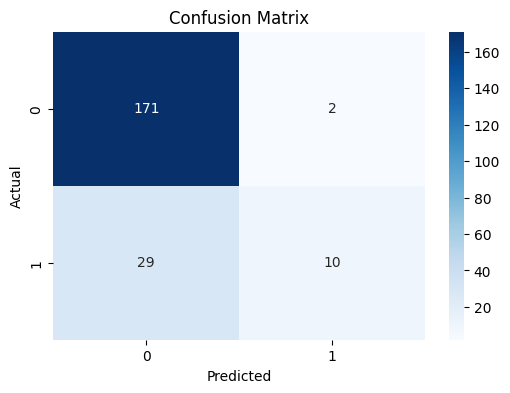

In [ ]:
# Prediksi
y_pred = model.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Melakukan tahap uji pada model machine learning. Hasil laporan klasifikasi menunjukkan bahwa model mampu memprediksi attrition dengan persentase akurasi sebesar 85%. Akurasi ini dapat dianggap model cukup baik dalam melakukan prediksi

# Deployment

In [ ]:
# Load model
loaded_model = joblib.load('model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

In [ ]:
df_dummy = pd.DataFrame({
    "MonthlyIncome": [13500],
    "StockOptionLevel": [1],
    "JobLevel": [4],
    "Age": [42],
    "TotalWorkingYears": [23],
    "OverTime_No": [1], # OverTime: No
    "OverTime_Yes": [0],
    "MaritalStatus_Divorced": [0],
    "MaritalStatus_Married": [1],
    "MaritalStatus_Single": [0],
    "JobRole_Healthcare Representative": [0],
    "JobRole_Human Resources": [0],
    "JobRole_Laboratory Technician": [0],
    "JobRole_Manager": [0],
    "JobRole_Manufacturing Director": [0],
    "JobRole_Research Director": [0],
    "JobRole_Research Scientist": [0],
    "JobRole_Sales Executive": [0],
    "JobRole_Sales Representative": [1], # JobRole sebagai Sales Representative
    "Department_Human Resources": [0],
    "Department_Research & Development": [0],
    "Department_Sales":[1], # Department Sales
})

# Scaling dummy input
df_dummy_scaled = loaded_scaler.transform(df_dummy)

# Mapping hasil prediksi
mapping = {0: "Karyawan kemungkinan akan Stay", 1: "Karyawan kemungkinan akan Leave"}

# Prediksi menggunakan model
prediction = loaded_model.predict(df_dummy_scaled)
probabilities = loaded_model.predict_proba(df_dummy_scaled)

# Probabilitas untuk Stay (Attrition: 0) dan Leave (Attrition: 1)
proba_stay = probabilities[:, 0] * 100 # Probabilitas untuk Stay
proba_leave = probabilities[:, 1] * 100 # Probabilitas untuk Leave

# Tampilkan hasil
print(f"Prediksi Attrition: {mapping[prediction[0]]}")
print(f"Probabilitas Stay: {proba_stay[0]:.2f}%")
print(f"Probabilitas Leave: {proba_leave[0]:.2f}%")

Prediksi Attrition: Karyawan kemungkinan akan Stay
Probabilitas Stay: 77.64%
Probabilitas Leave: 22.36%


In [ ]:
pip freeze > requirements.txt